In [35]:
import pandas as pd


In [36]:
!pip install imageio-ffmpeg

In [37]:
import imageio_ffmpeg as ffmpeg

print(ffmpeg.get_ffmpeg_exe())

C:\Users\anish\AppData\Local\Programs\Python\Python312\Lib\site-packages\imageio_ffmpeg\binaries\ffmpeg-win-x86_64-v7.1.exe


In [38]:
import imageio_ffmpeg as ffmpeg
import subprocess

input_file = r"C:\Users\anish\Downloads\WhatsApp Audio 2026-06-26 at 3.34.28 PM.mp4"
output_file = "voice.wav"

subprocess.run([
    ffmpeg.get_ffmpeg_exe(),
    "-y",                  # Force overwrite
    "-i", input_file,
    "-ac", "1",
    "-ar", "16000",
    output_file
], check=True)

print("Conversion completed")

Conversion completed


In [39]:
import os

print(os.path.exists("voice.wav"))

True


In [40]:
import librosa

audio, sr = librosa.load("voice.wav", sr=16000)

print("Loaded successfully")
print("Sample Rate =", sr)
print("Number of Samples =", len(audio))

Loaded successfully
Sample Rate = 16000
Number of Samples = 3010901


In [41]:
duration = len(audio) / sr

print("Duration =", round(duration, 2), "seconds")


Duration = 188.18 seconds


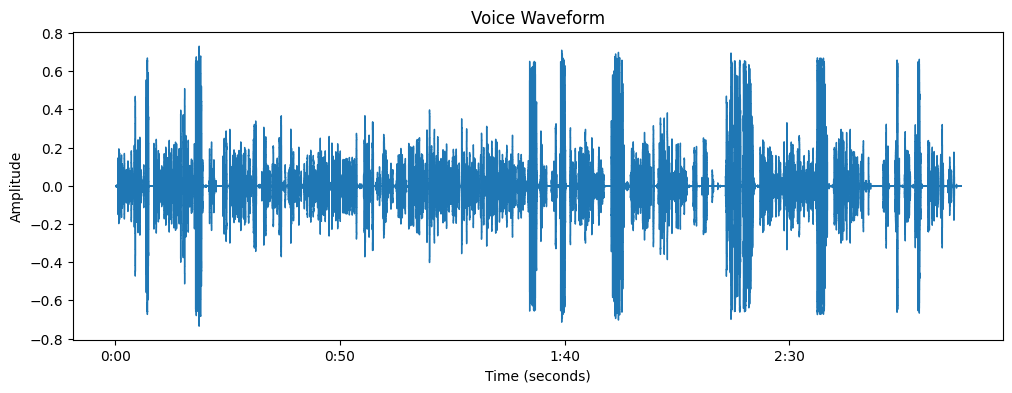

In [42]:
import matplotlib.pyplot as plt
import librosa.display

plt.figure(figsize=(12,4))
librosa.display.waveshow(audio, sr=sr)

plt.title("Voice Waveform")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")

plt.show()

In [43]:
import numpy as np

energy = np.mean(audio ** 2)

print("Energy =", energy)

Energy = 0.002560265


In [ ]:
f0, voiced_flag, voiced_probs = librosa.pyin(
    audio,
    fmin=75,
    fmax=600
)

import numpy as np

pitch = np.nanmean(f0)

print("Average Pitch =", pitch, "Hz")

In [ ]:
mfccs = librosa.feature.mfcc(
    y=audio,
    sr=sr,
    n_mfcc=13
)

print("MFCC Shape =", mfccs.shape)

In [ ]:
import numpy as np

mfcc_mean = np.mean(mfccs, axis=1)

print("MFCC Mean Features:")
print(mfcc_mean)
print("Length =", len(mfcc_mean))

In [14]:
import numpy as np

feature_vector = np.concatenate([
    [pitch],
    [energy],
    mfcc_mean
])

print("Feature Vector Length =", len(feature_vector))
print(feature_vector)

Feature Vector Length = 15
[ 3.42797973e+02  2.56026490e-03 -3.88727386e+02  9.55021896e+01
 -1.47697029e+01  9.05182362e+00 -1.28745203e+01 -2.92427521e+01
 -3.20280695e+00 -1.36525288e+01 -1.51664019e+01 -2.60226226e+00
 -1.00112495e+01 -9.77141285e+00 -4.88055086e+00]


In [16]:

import zipfile
import os

# ✅ Your 4 downloaded ZIP paths — update if needed
zip_files = [
    r"C:\Users\anish\Downloads\BhavVani-20260629T073441Z-3-001.zip",
    r"C:\Users\anish\Downloads\BhavVani-20260629T073441Z-3-002.zip",
    r"C:\Users\anish\Downloads\BhavVani-20260629T073441Z-3-003.zip",
    r"C:\Users\anish\Downloads\BhavVani-20260629T073441Z-3-004.zip",
]

# Extract all to a common folder
EXTRACT_DIR = r"C:\Users\anish\Downloads\BhavVani_Dataset"
os.makedirs(EXTRACT_DIR, exist_ok=True)

for zf in zip_files:
    print(f"Extracting {os.path.basename(zf)}...")
    with zipfile.ZipFile(zf, 'r') as z:
        z.extractall(EXTRACT_DIR)

print("\n✅ All ZIPs extracted to:", EXTRACT_DIR)

Extracting BhavVani-20260629T073441Z-3-001.zip...
Extracting BhavVani-20260629T073441Z-3-002.zip...
Extracting BhavVani-20260629T073441Z-3-003.zip...
Extracting BhavVani-20260629T073441Z-3-004.zip...

✅ All ZIPs extracted to: C:\Users\anish\Downloads\BhavVani_Dataset


In [17]:
# Inspect what's inside — understand folder structure
for root, dirs, files in os.walk(EXTRACT_DIR):
    level = root.replace(EXTRACT_DIR, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f"{indent}{os.path.basename(root)}/")
    if level < 3:  # Only show files 3 levels deep
        subindent = ' ' * 2 * (level + 1)
        for f in files[:5]:  # Show first 5 files per folder
            print(f"{subindent}{f}")
        if len(files) > 5:
            print(f"{subindent}... and {len(files)-5} more files")
     

BhavVani_Dataset/
  BhavVani/
    Annotated_Data.xlsx
    Hindi-SER Dataset Annotation Guidelines.docx
    Videos/
      Test/
      Train/
      Val/


In [18]:
!pip install openpyxl

In [19]:
# STEP 2 — Read the label Excel file
import pandas as pd

xlsx_path = r"C:\Users\anish\Downloads\BhavVani_Dataset\BhavVani\Annotated_Data.xlsx"

df = pd.read_excel(xlsx_path)
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape: (7991, 4)

Columns: ['Audio File', 'Speaker', 'Gender', 'Final Annotation']

First 5 rows:


,Audio File,Speaker,Gender,Final Annotation
0,train_1000_1.mp4,NaN,M,Neutral
1,train_1000_2.mp4,Sahil,M,Surprise
2,train_1000_3.mp4,NaN,M,Enjoyment
3,train_1000_4.mp4,Roshesh,M,Neutral
4,train_1000_5.mp4,NaN,M,Enjoyment


In [20]:
# STEP 3 — Check emotion classes + find where MP4s actually live
print("Emotion classes:")
print(df['Final Annotation'].value_counts())

print("\nTotal files:", len(df))
print("Null emotions:", df['Final Annotation'].isna().sum())

# Check which split each file belongs to (train/test/val prefix in filename)
df['split'] = df['Audio File'].apply(lambda x: x.split('_')[0])
print("\nSplit distribution:")
print(df['split'].value_counts())

Emotion classes:
Final Annotation
Enjoyment     1834
Neutral       1513
Disgust       1449
Anger         1213
Surprise       776
Sadness        555
Fear           450
Sadness          3
Enjoyment        3
 Sadness         1
sadness          1
enjoyment        1
Name: count, dtype: int64

Total files: 7991
Null emotions: 192

Split distribution:
split
train    6266
val       881
test      844
Name: count, dtype: int64


In [21]:
import os

# The filename prefix tells us which subfolder it's in
BASE_DIR = r"C:\Users\anish\Downloads\BhavVani_Dataset\BhavVani\Videos"

def get_video_path(filename):
    split = filename.split('_')[0]   # 'train', 'test', or 'val'
    folder = split.capitalize()       # 'Train', 'Test', 'Val'
    return os.path.join(BASE_DIR, folder, filename)

# Test on first 5 rows
for fname in df['Audio File'].head(5):
    path = get_video_path(fname)
    exists = os.path.exists(path)
    print(f"{'✅' if exists else '❌'}  {path}")

✅  C:\Users\anish\Downloads\BhavVani_Dataset\BhavVani\Videos\Train\train_1000_1.mp4
✅  C:\Users\anish\Downloads\BhavVani_Dataset\BhavVani\Videos\Train\train_1000_2.mp4
✅  C:\Users\anish\Downloads\BhavVani_Dataset\BhavVani\Videos\Train\train_1000_3.mp4
✅  C:\Users\anish\Downloads\BhavVani_Dataset\BhavVani\Videos\Train\train_1000_4.mp4
✅  C:\Users\anish\Downloads\BhavVani_Dataset\BhavVani\Videos\Train\train_1000_5.mp4


In [22]:
# STEP 4 — Clean the labels

# Fix messy emotion labels (strip spaces, title case)
df['Final Annotation'] = df['Final Annotation'].str.strip().str.title()

# Drop nulls
df = df.dropna(subset=['Final Annotation'])

print("After cleaning:")
print(df['Final Annotation'].value_counts())
print("\nTotal usable files:", len(df))

After cleaning:
Final Annotation
Enjoyment    1838
Neutral      1513
Disgust      1449
Anger        1213
Surprise      776
Sadness       560
Fear          450
Name: count, dtype: int64

Total usable files: 7799


In [23]:
import librosa
import numpy as np
import subprocess
import tempfile
import imageio_ffmpeg as ffmpeg
import os
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

def extract_features_from_mp4(mp4_path):
    tmp = tempfile.NamedTemporaryFile(suffix='.wav', delete=False)
    tmp.close()
    try:
        subprocess.run([
            ffmpeg.get_ffmpeg_exe(), "-y",
            "-i", mp4_path,
            "-ac", "1", "-ar", "16000",
            tmp.name
        ], check=True, capture_output=True)

        audio, sr = librosa.load(tmp.name, sr=16000)
        if len(audio) < 100:
            return None

        mfccs = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40)
        mfcc_mean = np.mean(mfccs, axis=1)
        mfcc_std  = np.std(mfccs, axis=1)

        chroma = librosa.feature.chroma_stft(y=audio, sr=sr)
        chroma_mean = np.mean(chroma, axis=1)

        mel = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=128)
        mel_db = librosa.power_to_db(mel, ref=np.max)
        mel_mean = np.mean(mel_db, axis=1)

        centroid = np.mean(librosa.feature.spectral_centroid(y=audio, sr=sr))
        zcr = np.mean(librosa.feature.zero_crossing_rate(y=audio))

        pitches, _ = librosa.piptrack(y=audio, sr=sr, fmin=75, fmax=600)
        pitch = float(np.mean(pitches[pitches > 0])) if np.any(pitches > 0) else 0.0
        energy = np.mean(audio ** 2)

        return np.concatenate([
            mfcc_mean, mfcc_std,
            chroma_mean,
            mel_mean,
            [centroid, zcr, pitch, energy]
        ])

    except:
        return None
    finally:
        os.unlink(tmp.name)


# Quick test first
test_path = get_video_path(df['Audio File'].iloc[0])
result = extract_features_from_mp4(test_path)
print("Feature length:", len(result) if result is not None else "FAILED")

Feature length: 224


In [31]:
X, y, failed = [], [], []

for _, row in tqdm(df.iterrows(), total=len(df), desc="Extracting"):
    path = get_video_path(row['Audio File'])
    features = extract_features_from_mp4(path)
    if features is not None:
        X.append(features)
        y.append(row['Final Annotation'])
    else:
        failed.append(row['Audio File'])

X = np.array(X)
y = np.array(y)

np.save(os.path.join(SAVE_DIR, "X.npy"), X)
np.save(os.path.join(SAVE_DIR, "y.npy"), y)

print(f"X shape: {X.shape}")
print(f"Failed:  {len(failed)}")

Extracting: 100%|██████████| 7799/7799 [36:18<00:00,  3.58it/s]  


X shape: (7799, 224)
Failed:  0


In [32]:
X, y, failed = [], [], []


SAVE_DIR = r"C:\Users\anish\Downloads\BhavVani_Features"

np.save(os.path.join(SAVE_DIR, "X.npy"), X)
np.save(os.path.join(SAVE_DIR, "y.npy"), y)

print(f"X shape: {X.shape}")
print(f"Failed:  {len(failed)}")

AttributeError: 'list' object has no attribute 'shape'

In [33]:
X = np.load(r"C:\Users\anish\Downloads\BhavVani_Features\X.npy")
y = np.load(r"C:\Users\anish\Downloads\BhavVani_Features\y.npy", allow_pickle=True)

In [34]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Classes:", le.classes_)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled, y_encoded, test_size=0.30, random_state=42, stratify=y_encoded
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f"Train: {X_train.shape[0]}")
print(f"Val:   {X_val.shape[0]}")
print(f"Test:  {X_test.shape[0]}")

Classes: []


ValueError: Expected 2D array, got 1D array instead:
array=[].
Reshape your data either using array.reshape(-1, 1) if your data has a single feature or array.reshape(1, -1) if it contains a single sample.

In [42]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

X_tr = torch.tensor(X_train, dtype=torch.float32)
y_tr = torch.tensor(y_train, dtype=torch.long)
X_v  = torch.tensor(X_val,   dtype=torch.float32)
y_v  = torch.tensor(y_val,   dtype=torch.long)
X_te = torch.tensor(X_test,  dtype=torch.float32)
y_te = torch.tensor(y_test,  dtype=torch.long)

train_loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=64, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_v,  y_v),  batch_size=64)

class EmotionMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(224, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 7)
        )
    def forward(self, x):
        return self.net(x)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = EmotionMLP().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

print(f"Device: {device}")
print(f"Model ready")

Device: cpu
Model ready


In [43]:
EPOCHS = 50
best_val_acc = 0
train_losses, val_accs = [], []

for epoch in range(EPOCHS):
    # Train
    model.train()
    total_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    # Validate
    model.eval()
    correct = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            preds = model(xb).argmax(dim=1)
            correct += (preds == yb).sum().item()

    val_acc = correct / len(X_val)
    avg_loss = total_loss / len(train_loader)
    scheduler.step(avg_loss)

    train_losses.append(avg_loss)
    val_accs.append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), os.path.join(SAVE_DIR, 'best_model.pt'))

    print(f"Epoch [{epoch+1:02d}/{EPOCHS}] | Loss: {avg_loss:.4f} | Val Acc: {val_acc*100:.2f}% | Best: {best_val_acc*100:.2f}%")

print(f"\nTraining complete! Best Val Accuracy: {best_val_acc*100:.2f}%")

Epoch [01/50] | Loss: 1.7997 | Val Acc: 29.15% | Best: 29.15%
Epoch [02/50] | Loss: 1.7020 | Val Acc: 31.20% | Best: 31.20%
Epoch [03/50] | Loss: 1.6325 | Val Acc: 31.79% | Best: 31.79%
Epoch [04/50] | Loss: 1.5681 | Val Acc: 32.22% | Best: 32.22%
Epoch [05/50] | Loss: 1.5031 | Val Acc: 33.50% | Best: 33.50%
Epoch [06/50] | Loss: 1.4521 | Val Acc: 33.42% | Best: 33.50%
Epoch [07/50] | Loss: 1.4000 | Val Acc: 35.38% | Best: 35.38%
Epoch [08/50] | Loss: 1.3425 | Val Acc: 34.79% | Best: 35.38%
Epoch [09/50] | Loss: 1.2912 | Val Acc: 36.07% | Best: 36.07%
Epoch [10/50] | Loss: 1.2448 | Val Acc: 36.24% | Best: 36.24%
Epoch [11/50] | Loss: 1.2024 | Val Acc: 35.64% | Best: 36.24%
Epoch [12/50] | Loss: 1.1633 | Val Acc: 37.95% | Best: 37.95%
Epoch [13/50] | Loss: 1.1226 | Val Acc: 36.15% | Best: 37.95%
Epoch [14/50] | Loss: 1.0893 | Val Acc: 37.52% | Best: 37.95%
Epoch [15/50] | Loss: 1.0463 | Val Acc: 38.12% | Best: 38.12%
Epoch [16/50] | Loss: 1.0189 | Val Acc: 37.95% | Best: 38.12%
Epoch [1

In [1]:

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Reload best checkpoint
model.load_state_dict(torch.load(os.path.join(SAVE_DIR, 'best_model.pt')))
model.eval()

X_te = torch.tensor(X_test, dtype=torch.float32).to(device)
with torch.no_grad():
    test_preds = model(X_te).argmax(dim=1).cpu().numpy()

print("Test Accuracy:", (test_preds == y_test).mean())
print("\nClassification Report:\n", classification_report(y_test, test_preds, target_names=le.classes_))

cm = confusion_matrix(y_test, test_preds)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_, cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Test Set")
plt.show()

NameError: name 'model' is not defined

In [44]:
print("hello")

hello


Test Accuracy: 37.44%
              precision    recall  f1-score   support

       Anger       0.40      0.37      0.39       182
     Disgust       0.37      0.46      0.41       217
   Enjoyment       0.42      0.53      0.47       275
        Fear       0.27      0.13      0.18        68
     Neutral       0.35      0.26      0.30       227
     Sadness       0.25      0.24      0.24        84
    Surprise       0.34      0.32      0.33       117

    accuracy                           0.37      1170
   macro avg       0.34      0.33      0.33      1170
weighted avg       0.37      0.37      0.37      1170



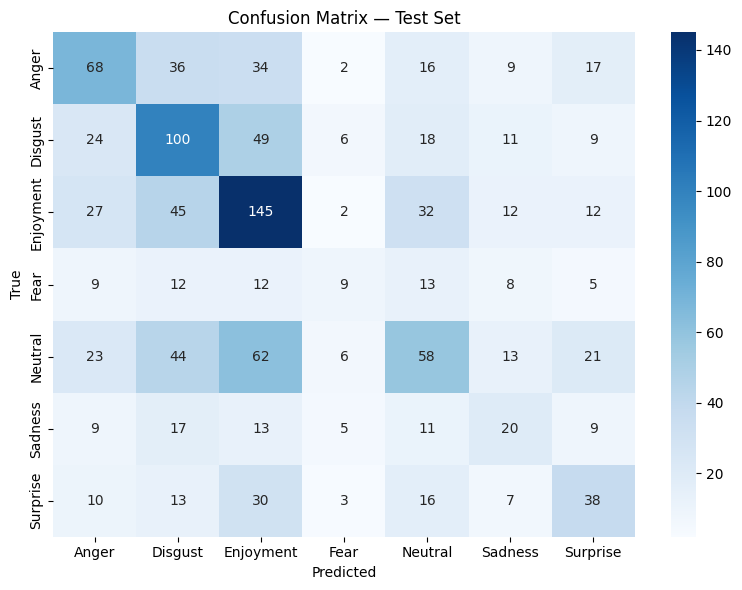

In [65]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Load best model
model.load_state_dict(torch.load(os.path.join(SAVE_DIR, 'best_model.pt')))
model.eval()

with torch.no_grad():
    logits = model(X_te.to(device))
    y_pred = logits.argmax(dim=1).cpu().numpy()

acc = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {acc*100:.2f}%")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix — Test Set')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

In [ ]:
import joblib

joblib.dump(scaler, os.path.join(SAVE_DIR, 'scaler.pkl'))
joblib.dump(le,     os.path.join(SAVE_DIR, 'label_encoder.pkl'))

print("Saved:")
print(f"  best_model.pt")
print(f"  scaler.pkl")
print(f"  label_encoder.pkl")

In [68]:

def predict_emotion(file_path, temperature=3.0):
    features = extract_features_from_mp4(file_path)
    if features is None:
        print("❌ Could not extract features")
        return

    features_scaled = scaler.transform([features])

    model.eval()
    with torch.no_grad():
        inp = torch.tensor(features_scaled, dtype=torch.float32).to(device)
        logits = model(inp)
        # divide by temperature to soften overconfident predictions
        proba = torch.softmax(logits / temperature, dim=1).cpu().numpy()[0]
        pred = proba.argmax()

    emotion = le.inverse_transform([pred])[0]
    confidence = proba.max() * 100

    print(f"\n🎯 Predicted Emotion : {emotion.upper()}")
    print(f"   Confidence        : {confidence:.1f}%")
    print(f"\n   All probabilities:")
    for em, prob in sorted(zip(le.classes_, proba), key=lambda x: -x[1]):
        bar = '█' * int(prob * 30)
        print(f"   {em:12s} {bar:30s} {prob*100:.1f}%")

    return emotion


# Test on a few different files to see variety
for i in [0, 10, 50, 100, 200]:
    print(f"\n--- File {i}: {df['Audio File'].iloc[i]} (True: {df['Final Annotation'].iloc[i]}) ---")
    predict_emotion(get_video_path(df['Audio File'].iloc[i]))


--- File 0: train_1000_1.mp4 (True: Neutral) ---

🎯 Predicted Emotion : NEUTRAL
   Confidence        : 100.0%

   All probabilities:
   Neutral      ██████████████████████████████ 100.0%
   Anger                                       0.0%
   Disgust                                     0.0%
   Enjoyment                                   0.0%
   Fear                                        0.0%
   Sadness                                     0.0%
   Surprise                                    0.0%

--- File 10: train_1002_2.mp4 (True: Anger) ---

🎯 Predicted Emotion : NEUTRAL
   Confidence        : 100.0%

   All probabilities:
   Neutral      ██████████████████████████████ 100.0%
   Anger                                       0.0%
   Disgust                                     0.0%
   Enjoyment                                   0.0%
   Fear                                        0.0%
   Sadness                                     0.0%
   Surprise                                    0.0%



In [77]:
import torch
import torch.nn as nn
import numpy as np
import librosa
import subprocess
import tempfile
import imageio_ffmpeg as ffmpeg
import joblib
import os

SAVE_DIR = r"C:\Users\anish\Downloads\BhavVani_Features"

# ─── paste your mp4 path here ───────────────────────────
MY_FILE = r"C:\Users\anish\Downloads\WhatsApp Audio 2026-06-29 at 10.25.19 PM.mp4"
# ────────────────────────────────────────────────────────

class EmotionMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(224, 512), nn.BatchNorm1d(512), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(512, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, 128), nn.ReLU(),
            nn.Linear(128, 7)
        )
    def forward(self, x):
        return self.net(x)

def extract_features(mp4_path):
    tmp = tempfile.NamedTemporaryFile(suffix='.wav', delete=False)
    tmp.close()
    try:
        subprocess.run([
            ffmpeg.get_ffmpeg_exe(), "-y", "-i", mp4_path,
            "-ac", "1", "-ar", "16000", tmp.name
        ], check=True, capture_output=True)
        audio, sr = librosa.load(tmp.name, sr=16000)
        mfccs = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40)
        chroma = librosa.feature.chroma_stft(y=audio, sr=sr)
        mel = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=128)
        pitches, _ = librosa.piptrack(y=audio, sr=sr, fmin=75, fmax=600)
        pitch = float(np.mean(pitches[pitches > 0])) if np.any(pitches > 0) else 0.0
        return np.concatenate([
            np.mean(mfccs, axis=1), np.std(mfccs, axis=1),
            np.mean(chroma, axis=1), np.mean(mel, axis=1),
            [np.mean(librosa.feature.spectral_centroid(y=audio, sr=sr)),
             np.mean(librosa.feature.zero_crossing_rate(y=audio)),
             pitch, np.mean(audio ** 2)]
        ])
    except:
        return None
    finally:
        os.unlink(tmp.name)

# Load saved model + scaler + encoder
device = torch.device('cpu')
model = EmotionMLP().to(device)
model.load_state_dict(torch.load(os.path.join(SAVE_DIR, 'best_model.pt'), map_location=device))
model.eval()
scaler = joblib.load(os.path.join(SAVE_DIR, 'scaler.pkl'))
le     = joblib.load(os.path.join(SAVE_DIR, 'label_encoder.pkl'))

# Predict
features = extract_features(MY_FILE)
if features is None:
    print("❌ Could not extract features — check the file path")
else:
    scaled = scaler.transform([features])
    with torch.no_grad():
        logits = model(torch.tensor(scaled, dtype=torch.float32))
        proba  = torch.softmax(logits / 3.0, dim=1).numpy()[0]
        pred   = proba.argmax()

    emotion = le.inverse_transform([pred])[0]
    print(f"\n🎯 Predicted Emotion : {emotion.upper()}")
    print(f"   Confidence        : {proba.max()*100:.1f}%")
    print(f"\n   All probabilities:")
    for em, prob in sorted(zip(le.classes_, proba), key=lambda x: -x[1]):
        bar = '█' * int(prob * 30)
        print(f"   {em:12s} {bar:30s} {prob*100:.1f}%")


🎯 Predicted Emotion : ENJOYMENT
   Confidence        : 97.6%

   All probabilities:
   Enjoyment    █████████████████████████████  97.6%
   Disgust                                     2.3%
   Neutral                                     0.1%
   Anger                                       0.0%
   Sadness                                     0.0%
   Fear                                        0.0%
   Surprise                                    0.0%
